In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
# import shap
import os
for dirname,  _, filenames in os.walk('assets'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

assets\sample_submission.csv
assets\test.csv
assets\train.csv


In [38]:
train_df = pd.read_csv('assets/train.csv')
test_df = pd.read_csv('assets/test.csv')
X = train_df.drop(['id', 'diagnosed_diabetes'], axis=1)
y = train_df['diagnosed_diabetes']

X_test = test_df.drop('id', axis=1)

In [39]:
numeric_feature = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_feature = X.select_dtypes(include=['object']).columns.tolist()
print(f"numeric_feature: {numeric_feature}")
print(f"categorical_feature: {categorical_feature}")

numeric_feature: ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history']
categorical_feature: ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']


In [40]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12,8]

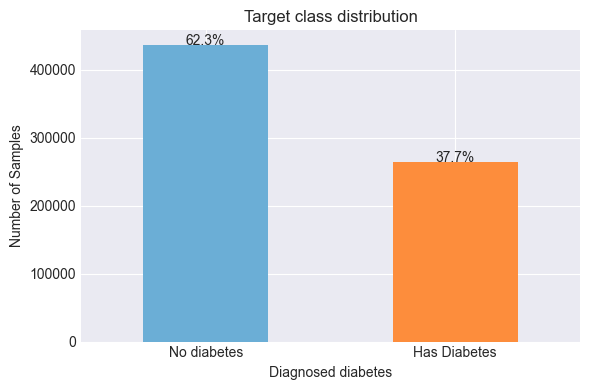

In [41]:
counts = train_df['diagnosed_diabetes'].value_counts(normalize=True)*100
plt.figure(figsize=(6,4))
ax = train_df['diagnosed_diabetes'].value_counts().plot(
    kind='bar',
    color=['#6baed6', '#fd8d3c']
)

plt.title('Target class distribution')
plt.xlabel('Diagnosed diabetes')
plt.ylabel('Number of Samples')
plt.xticks([0,1], ['No diabetes', 'Has Diabetes'], rotation=0)

for i, v in enumerate(train_df['diagnosed_diabetes'].value_counts()):
    ax.text(i, v + 500, f"{counts.iloc[i]:.1f}%", ha='center')

plt.tight_layout()
plt.show()

In [42]:
train_encoded = train_df.copy()
for col in categorical_feature:
    train_encoded[col] = pd.factorize(train_df[col])[0]

all_feature = numeric_feature + categorical_feature + ['diagnosed_diabetes']
corr_matrix = train_encoded[all_feature].corr()

Top 10 features by correlation with the target variable:
diagnosed_diabetes                    1.000000
family_history_diabetes               0.211064
physical_activity_minutes_per_week    0.169789
age                                   0.161162
systolic_bp                           0.107132
bmi                                   0.105580
ldl_cholesterol                       0.102771
triglycerides                         0.090635
cholesterol_total                     0.088112
waist_to_hip_ratio                    0.081050
hdl_cholesterol                       0.053231
Name: diagnosed_diabetes, dtype: float64


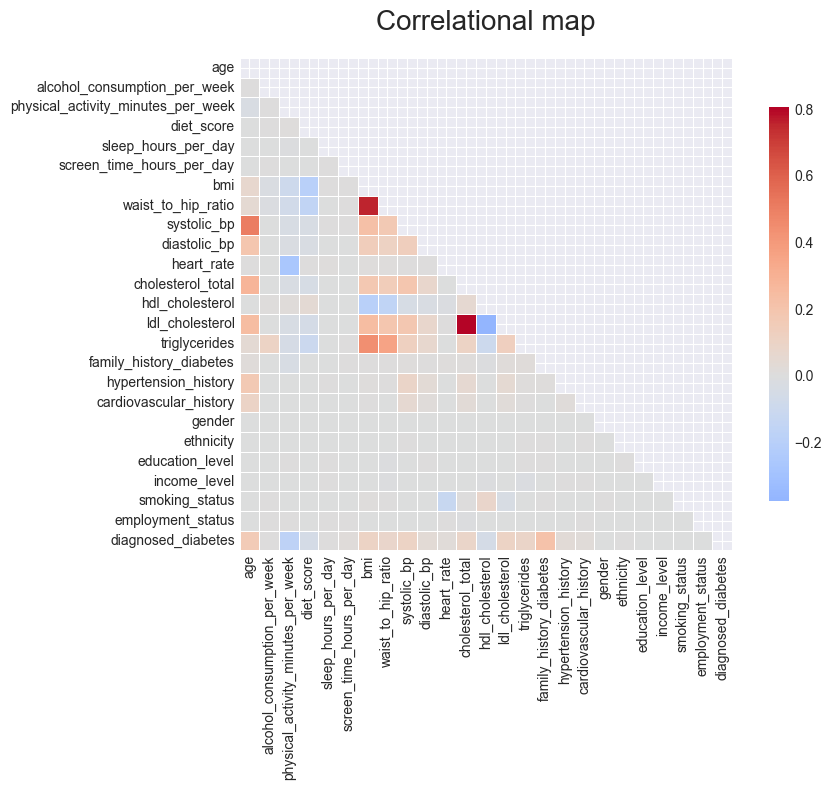

In [43]:
target_corr = corr_matrix['diagnosed_diabetes'].sort_values(ascending=False)
print("Top 10 features by correlation with the target variable:")
print(target_corr.abs().sort_values(ascending=False).head(11))
plt.figure(figsize=(10, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            cmap = 'coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink":0.8},
            annot = False)

plt.title('Correlational map', fontsize=20, pad=20)
plt.tight_layout()
plt.show()

In [44]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_feature),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_feature)
    ]
)

In [45]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [46]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [47]:
X_train.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history
count,560000.000000,560000.000000,560000.000000,560000.000000,560000.000000,560000.000000,560000.000000,560000.000000,560000.000000,560000.000000,560000.000000,560000.000000,560000.00000,560000.000000,560000.000000,560000.000000,560000.000000,560000.000000
mean,50.360098,2.071616,80.213493,5.963169,7.001611,6.011431,25.873794,0.858766,116.295496,75.440743,70.171162,186.826730,53.81910,102.923093,123.085934,0.149280,0.182143,0.030366
std,11.653191,1.047199,51.172618,1.463713,0.901866,2.023708,2.859788,0.037979,11.008420,6.823348,6.936900,16.731938,8.27154,19.025241,24.746970,0.356365,0.385963,0.171593
min,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.00000,51.000000,31.000000,0.000000,0.000000,0.000000
25%,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,48.00000,89.000000,106.000000,0.000000,0.000000,0.000000
50%,50.000000,2.000000,71.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.00000,103.000000,123.000000,0.000000,0.000000,0.000000
75%,58.000000,3.000000,96.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.00000,116.000000,139.000000,0.000000,0.000000,0.000000
max,89.000000,9.000000,747.000000,9.900000,9.900000,16.500000,38.400000,1.050000,163.000000,104.000000,101.000000,289.000000,90.00000,205.000000,290.000000,1.000000,1.000000,1.000000


In [48]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [49]:
val_preds = model.predict_proba(X_val)[:, 1]
val_score = roc_auc_score(y_val, val_preds)
print(f"\nROC-AUC on validation: {val_score:.4f}")


ROC-AUC on validation: 0.6926


LogReg

In [53]:
logreg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        n_jobs=1
    ))
])

logreg.fit(X_train, y_train)
val_preds = logreg.predict_proba(X_val)[:, 1]
print("LogReg ROC-AUC:", roc_auc_score(y_val, val_preds))

c:\Users\Sakshan Sharma\OneDrive\Desktop\codes\machine-learning\nlp_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


LogReg ROC-AUC: 0.6948567682279685


CatBoost

In [54]:
cat_features = categorical_feature

In [55]:
cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    task_type='GPU',
    verbose=200,
    auto_class_weights='Balanced'
)

cat_model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    use_best_model=True
)

val_preds = cat_model.predict_proba(X_val)[:, 1]
print("CatBoost ROC-AUC:", roc_auc_score(y_val, val_preds))

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.6809012	best: 0.6809012 (0)	total: 181ms	remaining: 3m 1s
200:	test: 0.7129070	best: 0.7129070 (200)	total: 19.8s	remaining: 1m 18s
400:	test: 0.7195767	best: 0.7195767 (400)	total: 39.2s	remaining: 58.5s
600:	test: 0.7223602	best: 0.7223602 (600)	total: 58.6s	remaining: 38.9s
800:	test: 0.7236648	best: 0.7236648 (800)	total: 1m 18s	remaining: 19.4s
999:	test: 0.7243255	best: 0.7243255 (999)	total: 1m 37s	remaining: 0us
bestTest = 0.7243255079
bestIteration = 999
CatBoost ROC-AUC: 0.7243254604012771


In [56]:
final_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    random_seed=42,
    auto_class_weights='Balanced',
    task_type='GPU',
    verbose=200
)

final_model.fit(
    X, y,
    cat_features=cat_features
)

0:	learn: 0.6871905	total: 143ms	remaining: 2m 22s
200:	learn: 0.6174941	total: 23.9s	remaining: 1m 35s
400:	learn: 0.6117317	total: 46.5s	remaining: 1m 9s
600:	learn: 0.6088381	total: 1m 9s	remaining: 45.9s
800:	learn: 0.6067970	total: 1m 31s	remaining: 22.8s
999:	learn: 0.6051374	total: 1m 54s	remaining: 0us


In [57]:
test_preds = final_model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'id': test_df['id'],
    'diagnosed_diabetes': test_preds
})

submission.to_csv('assets\cat_boost_full.csv', index=False)

In [58]:
cat_probe = CatBoostClassifier(
    iterations=6000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    auto_class_weights='Balanced',
    task_type='GPU',
    verbose=100
)

cat_probe.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    use_best_model=True
)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.6809012	best: 0.6809012 (0)	total: 113ms	remaining: 11m 20s
100:	test: 0.7061739	best: 0.7061739 (100)	total: 10.6s	remaining: 10m 18s
200:	test: 0.7129069	best: 0.7129069 (200)	total: 20.1s	remaining: 9m 40s
300:	test: 0.7165599	best: 0.7165599 (300)	total: 29.6s	remaining: 9m 20s
400:	test: 0.7195766	best: 0.7195766 (400)	total: 39.4s	remaining: 9m 10s
500:	test: 0.7212089	best: 0.7212089 (500)	total: 49s	remaining: 8m 58s
600:	test: 0.7223601	best: 0.7223601 (600)	total: 58.5s	remaining: 8m 45s
700:	test: 0.7231715	best: 0.7231715 (700)	total: 1m 8s	remaining: 8m 35s
800:	test: 0.7236648	best: 0.7236648 (800)	total: 1m 18s	remaining: 8m 27s
900:	test: 0.7240404	best: 0.7240404 (900)	total: 1m 28s	remaining: 8m 18s
1000:	test: 0.7243307	best: 0.7243307 (1000)	total: 1m 38s	remaining: 8m 9s
1100:	test: 0.7245752	best: 0.7245752 (1100)	total: 1m 48s	remaining: 8m
1200:	test: 0.7248117	best: 0.7248117 (1200)	total: 1m 57s	remaining: 7m 51s
1300:	test: 0.7249157	best: 0.724915

In [59]:
final_model = CatBoostClassifier(
    iterations=3300,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    auto_class_weights='Balanced',
    task_type='GPU',
    verbose=200
)

final_model.fit(
    X, y,
    cat_features=cat_features
)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	total: 139ms	remaining: 7m 39s
200:	total: 23.9s	remaining: 6m 8s
400:	total: 46.4s	remaining: 5m 35s
600:	total: 1m 8s	remaining: 5m 9s
800:	total: 1m 31s	remaining: 4m 45s
1000:	total: 1m 54s	remaining: 4m 22s
1200:	total: 2m 17s	remaining: 3m 59s
1400:	total: 2m 40s	remaining: 3m 37s
1600:	total: 3m 4s	remaining: 3m 15s
1800:	total: 3m 27s	remaining: 2m 52s
2000:	total: 3m 50s	remaining: 2m 29s
2200:	total: 4m 14s	remaining: 2m 6s
2400:	total: 4m 37s	remaining: 1m 43s
2600:	total: 5m 1s	remaining: 1m 20s
2800:	total: 5m 24s	remaining: 57.8s
3000:	total: 5m 48s	remaining: 34.7s
3200:	total: 6m 11s	remaining: 11.5s
3299:	total: 6m 23s	remaining: 0us


In [60]:
lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        class_weight='balanced',
        random_state=42,
        device='gpu'
    ))
])

lgbm.fit(X_train, y_train)
val_preds = lgbm.predict_proba(X_val)[:, 1]
print("LGBM ROC-AUC:", roc_auc_score(y_val, val_preds))

[LightGBM] [Info] Number of positive: 349046, number of negative: 210954
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1663
[LightGBM] [Info] Number of data points in the train set: 560000, number of used features: 36
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 19 dense feature groups (10.68 MB) transferred to GPU in 0.015762 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\Sakshan Sharma\OneDrive\Desktop\codes\machine-learning\nlp_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGBM ROC-AUC: 0.7262328725266343


In [62]:
test_preds = lgbm.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'id': test_df['id'],
    'diagnosed_diabetes': test_preds
})
submission.to_csv('assets\lgbm_submission.csv', index=False)

c:\Users\Sakshan Sharma\OneDrive\Desktop\codes\machine-learning\nlp_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
